# Grantham Distance Analysis: Entrenched vs Non-Entrenched Substitutions

Test whether entrenched amino acid pairs are more physicochemically different
(larger Grantham distance) than non-entrenched pairs.

Grantham distance (Grantham 1974, Science) is a composite measure of amino acid
dissimilarity based on composition, polarity, and molecular volume.

Data source: comparison dataframes from the entrenchment analysis
(e.g. `comparison_within_IGHV1.csv`, `comparison_IGHV1_vs_IGHV3.csv`),
which contain all tested AA pairs with `is_entrenched` labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from utils import load_entrenched_sites

## Grantham Distance Matrix

Computed from the original Grantham (1974) formula using amino acid properties
(composition, polarity, volume) downloaded from the [AAindex database](https://www.genome.jp/aaindex/)
(entries GRAR740101–03).

- Grantham, R. *Science* 185(4154):862-4 (1974). doi:10.1126/science.185.4154.862
- Kawashima, S. & Kanehisa, M. *Nucleic Acids Res.* 28, 374 (2000). [AAindex database]

Requires: `pip install aaindex`

**Note on D-W discrepancy:** Recomputing all 190 pairwise distances from the
published formula and Table 1 properties reproduces Table 2 to within rounding
(median difference <0.3) for 189/190 pairs. The one exception is Asp-Trp (D-W):
the formula yields ~191, whereas Table 2 reports 181. This appears to be an
arithmetic error in the original 1974 paper; the R
[grantham](https://cran.r-project.org/web/packages/grantham/) package documents
the same discrepancy. We use the formula-derived value here for internal
consistency.

In [2]:
"""
Compute Grantham (1974) amino acid distances from the AAindex database.

No hardcoded distance values - everything is computed from:
  - AAindex entries GRAR740101 (composition), GRAR740102 (polarity), GRAR740103 (volume)
  - Grantham's formula with published parameters (alpha, beta, gamma, rho)
"""
import math
from aaindex import aaindex1

# Load amino acid properties from AAindex database (Grantham 1974 Table 1)
_comp = aaindex1['GRAR740101'].values  # Composition
_pol  = aaindex1['GRAR740102'].values  # Polarity
_vol  = aaindex1['GRAR740103'].values  # Volume

# Grantham formula parameters (from p. 863 of the paper)
# rho = 50.723 is from the Table 2 caption
ALPHA = 1.833    # weight for composition
BETA  = 0.1018   # weight for polarity
GAMMA = 0.000399 # weight for volume
RHO   = 50.723   # scaling factor so mean distance = 100


def grantham_distance(aa1, aa2):
    """
    Compute Grantham distance between two amino acids.

    Uses the formula from Grantham (1974):
        d = rho * sqrt(alpha*(c1-c2)^2 + beta*(p1-p2)^2 + gamma*(v1-v2)^2)
    """
    if aa1 == aa2:
        return 0.0
    c1, c2 = _comp[aa1], _comp[aa2]
    p1, p2 = _pol[aa1],  _pol[aa2]
    v1, v2 = _vol[aa1],  _vol[aa2]
    return RHO * math.sqrt(
        ALPHA * (c1 - c2)**2 +
        BETA  * (p1 - p2)**2 +
        GAMMA * (v1 - v2)**2
    )

# Spot-check against known Table 2 values
_spot_checks = {('A','R'): 112, ('I','L'): 5, ('D','E'): 45, ('C','W'): 215, ('S','T'): 58}
for (a1, a2), expected in _spot_checks.items():
    computed = grantham_distance(a1, a2)
    assert abs(computed - expected) <= 1.5, f"Mismatch: {a1}-{a2} computed={computed:.1f}, expected={expected}"
print("Grantham distances computed from AAindex properties (all spot checks passed)")

Grantham distances computed from AAindex properties (all spot checks passed)


## Load Comparison Dataframes

In [3]:
numbering_scheme = 'chothia'

_, _, pairwise_df_dict, _, _, _ = load_entrenched_sites(numbering_scheme)

print("Comparisons loaded:")
for name, pdf in pairwise_df_dict.items():
    print(f"  {name}: {len(pdf)} pairs, {pdf.is_entrenched.sum()} entrenched")

Comparisons loaded:
  IGHV3_vs_IGHV4: 114 pairs, 12 entrenched
  IGHV1_vs_IGHV4: 108 pairs, 9 entrenched
  IGHV1_vs_IGHV3: 202 pairs, 17 entrenched
  within_IGHV3: 260 pairs, 22 entrenched
  within_IGHV1: 190 pairs, 16 entrenched
  within_IGHV4: 68 pairs, 4 entrenched


## Compute Grantham Distance for All Pairs

In [4]:
all_pairs = []
for comparison_name, pdf in pairwise_df_dict.items():
    df_copy = pdf.copy()
    df_copy['comparison'] = comparison_name
    df_copy['comparison_type'] = 'within' if comparison_name.startswith('within_') else 'between'

    # Ensure is_entrenched is boolean
    df_copy['is_entrenched'] = df_copy['is_entrenched'].astype(bool)

    # For within-family comparisons, deduplicate symmetric pairs (A->B == B->A)
    if comparison_name.startswith('within_'):
        df_copy = df_copy[
            df_copy['parent_aa_1_and_target_aa_2'] <= df_copy['parent_aa_2_and_target_aa_1']
        ]

    df_copy['grantham'] = df_copy.apply(
        lambda r: grantham_distance(r['parent_aa_1_and_target_aa_2'], r['parent_aa_2_and_target_aa_1']),
        axis=1
    )
    all_pairs.append(df_copy)

all_pairs_df = pd.concat(all_pairs, ignore_index=True)
within_pairs = all_pairs_df[all_pairs_df['comparison_type'] == 'within']

print(f"Total pairs: {len(all_pairs_df)}")
print(f"  Within-family: {len(within_pairs):4d} ({within_pairs.is_entrenched.sum()} entrenched)")

Total pairs: 683
  Within-family:  259 (21 entrenched)


## Site-Specific Analysis & Permutation Diagnostic

Look at individual sites and visualize the permutation null distribution
to verify the test is working correctly.

Entrenched sites across IGHV1/IGHV3: ['33', '35', '50', '52', '53']


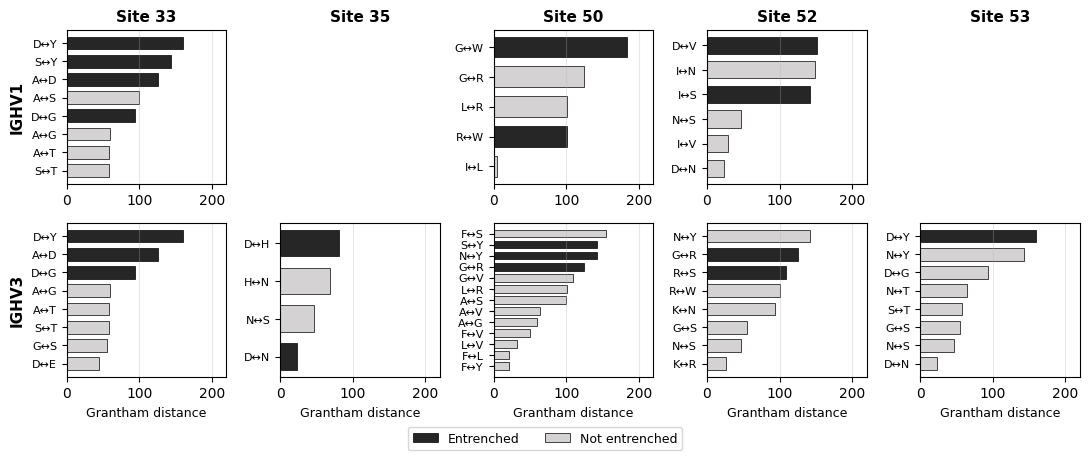

In [5]:
# Paper figure: Grantham distance at within-family entrenched sites
# Rows: IGHV1, IGHV3 | Columns: all sites with entrenchment in at least one family

v_families = ['IGHV1', 'IGHV3']

# Build within-family data with deduplication
site_data = within_pairs.copy()
site_data['substitution'] = (
    site_data['parent_aa_1_and_target_aa_2'] + '\u2194' + site_data['parent_aa_2_and_target_aa_1']
)

# Find all sites that are entrenched in at least one of the target v-families
entrenched_sites_set = set()
for vfam in v_families:
    comp = f'within_{vfam}'
    mask = (site_data.comparison == comp) & (site_data.is_entrenched == True)
    entrenched_sites_set.update(site_data.loc[mask, 'site'].unique())

# Sort sites numerically (handle possible insertion codes like '30A')
target_sites = sorted(entrenched_sites_set, key=lambda s: (int(''.join(c for c in s if c.isdigit())), s))
n_sites = len(target_sites)

print(f"Entrenched sites across IGHV1/IGHV3: {target_sites}")

# Track which (vfam, site) combos have entrenchment
has_entrenchment = {}
for vfam in v_families:
    comp = f'within_{vfam}'
    for site in target_sites:
        mask = (site_data.comparison == comp) & (site_data.site == site) & (site_data.is_entrenched == True)
        has_entrenchment[(vfam, site)] = mask.any()

fig, axes = plt.subplots(2, n_sites, figsize=(2.2 * n_sites, 4.4))

for row_idx, vfam in enumerate(v_families):
    comp = f'within_{vfam}'
    for col_idx, site in enumerate(target_sites):
        ax = axes[row_idx, col_idx]

        if not has_entrenchment[(vfam, site)]:
            # No entrenchment: keep subplot for layout but remove all axes content
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            sd = site_data[
                (site_data.site == site) & (site_data.comparison == comp)
            ].sort_values('grantham')

            y_pos = range(len(sd))
            colors = ['#262626' if e else '#D4D2D2' for e in sd['is_entrenched'].values]

            ax.barh(y_pos, sd['grantham'].values, color=colors,
                    edgecolor='black', linewidth=0.5, height=0.7)
            ax.set_yticks(list(y_pos))
            ax.set_yticklabels(sd['substitution'].values, fontsize=8)
            ax.set_xlim(0, 220)
            ax.grid(axis='x', alpha=0.3)

            # x-axis label on bottom row only
            if row_idx == len(v_families) - 1:
                ax.set_xlabel('Grantham distance', fontsize=9)

        # Column title on top row (always, even for empty subplots)
        if row_idx == 0:
            ax.set_title(f'Site {site}', fontsize=11, fontweight='bold')

        # Row label on leftmost column
        if col_idx == 0:
            ax.set_ylabel(vfam, fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#262626', edgecolor='black', linewidth=0.5, label='Entrenched'),
    Patch(facecolor='#D4D2D2', edgecolor='black', linewidth=0.5, label='Not entrenched'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.05), frameon=True)

fig.tight_layout()
fig.savefig('figures/grantham_distance_for_within_vfamily_entrenched.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Stratified Permutation Test

Test whether entrenched pairs have larger Grantham distances, stratified by site.
Within each site, permute the entrenched/non-entrenched labels, then average
the per-site mean differences across all sites. This controls for site-level
differences in amino acid composition.

In [6]:
def stratified_permutation_test(df, v_families, n_perm=10000, seed=42):
    """Stratified permutation test for Grantham distance difference.

    For each v-family, identifies sites with entrenchment, computes
    per-site mean Grantham difference (entrenched - not entrenched),
    then averages across sites. Permutations shuffle labels within
    each site independently.

    Returns results dict with observed statistic, p-value, null distribution.
    """
    rng = np.random.default_rng(seed)

    # Collect site-level data for all (vfam, site) combos with entrenchment
    site_groups = []
    for vfam in v_families:
        comp = f'within_{vfam}'
        vfam_data = df[(df.comparison == comp)].copy()
        for site in vfam_data.site.unique():
            site_sub = vfam_data[vfam_data.site == site]
            if site_sub.is_entrenched.any() and (~site_sub.is_entrenched).any():
                site_groups.append({
                    'vfam': vfam,
                    'site': site,
                    'grantham': site_sub['grantham'].values,
                    'is_entrenched': site_sub['is_entrenched'].values,
                    'n_entrenched': site_sub['is_entrenched'].sum(),
                })

    def compute_stratified_stat(groups, permute=False):
        """Compute average per-site mean difference."""
        diffs = []
        for g in groups:
            if permute:
                labels = rng.permutation(g['is_entrenched'])
            else:
                labels = g['is_entrenched']
            ent_mean = g['grantham'][labels].mean()
            not_ent_mean = g['grantham'][~labels].mean()
            diffs.append(ent_mean - not_ent_mean)
        return np.mean(diffs)

    # Observed statistic
    observed = compute_stratified_stat(site_groups, permute=False)

    # Null distribution
    null_dist = np.array([compute_stratified_stat(site_groups, permute=True) for _ in range(n_perm)])

    p_value = (null_dist >= observed).mean()

    # Per-site details
    site_details = []
    for g in site_groups:
        ent = g['grantham'][g['is_entrenched']]
        not_ent = g['grantham'][~g['is_entrenched']]
        site_details.append({
            'v_family': g['vfam'],
            'site': g['site'],
            'n_entrenched': len(ent),
            'n_not_entrenched': len(not_ent),
            'mean_entrenched': ent.mean(),
            'mean_not_entrenched': not_ent.mean(),
            'diff': ent.mean() - not_ent.mean(),
        })

    return {
        'observed': observed,
        'p_value': p_value,
        'null_dist': null_dist,
        'site_details': pd.DataFrame(site_details),
        'n_sites': len(site_groups),
    }


# Run stratified test for IGHV1 + IGHV3
result_stratified = stratified_permutation_test(
    within_pairs, ['IGHV1', 'IGHV3'], n_perm=10000
)

print(f"Stratified permutation test (IGHV1 + IGHV3 within-family)")
print(f"  Sites included: {result_stratified['n_sites']}")
print(f"  Observed avg per-site diff: {result_stratified['observed']:.1f}")
print(f"  p-value: {result_stratified['p_value']:.4f}")
print()
print("Per-site details:")
print(result_stratified['site_details'].to_string(index=False))

Stratified permutation test (IGHV1 + IGHV3 within-family)
  Sites included: 8
  Observed avg per-site diff: 59.3
  p-value: 0.0000

Per-site details:
v_family site  n_entrenched  n_not_entrenched  mean_entrenched  mean_not_entrenched      diff
   IGHV1   33             4                 4       130.640233            68.725052 61.915181
   IGHV1   50             2                 3       142.540347            77.288202 65.252145
   IGHV1   52             2                 4       146.905679            61.942074 84.963605
   IGHV3   33             3                 5       126.484516            55.127942 71.356574
   IGHV3   35             2                 2        52.121667            57.297315 -5.175648
   IGHV3   50             3                10       136.821982            71.418725 65.403257
   IGHV3   52             2                 6       117.171173            77.485603 39.685570
   IGHV3   53             1                 7       159.937407            69.004676 90.932731


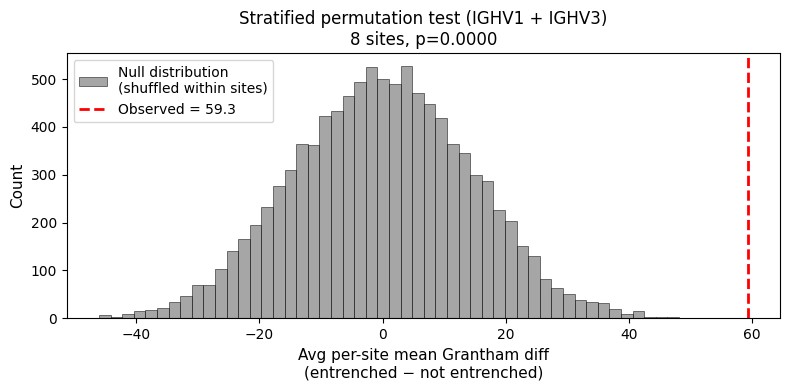

In [7]:
# Visualize stratified permutation null distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(result_stratified['null_dist'], bins=50, color='gray', alpha=0.7,
        edgecolor='black', linewidth=0.5, label='Null distribution\n(shuffled within sites)')
ax.axvline(result_stratified['observed'], color='red', linewidth=2, linestyle='--',
           label=f'Observed = {result_stratified["observed"]:.1f}')
ax.set_xlabel('Avg per-site mean Grantham diff\n(entrenched \u2212 not entrenched)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Stratified permutation test (IGHV1 + IGHV3)\n'
             f'{result_stratified["n_sites"]} sites, p={result_stratified["p_value"]:.4f}', fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

In [8]:
# Per v-family stratified tests
for vfam in ['IGHV1', 'IGHV3']:
    result_vfam = stratified_permutation_test(within_pairs, [vfam], n_perm=10000)
    print(f"Stratified permutation test: {vfam}")
    print(f"  Sites: {result_vfam['n_sites']}")
    print(f"  Observed avg per-site diff: {result_vfam['observed']:.1f}")
    print(f"  p-value: {result_vfam['p_value']:.4f}")
    print(f"  Per-site details:")
    print(result_vfam['site_details'].to_string(index=False))
    print()

Stratified permutation test: IGHV1
  Sites: 3
  Observed avg per-site diff: 70.7
  p-value: 0.0023
  Per-site details:
v_family site  n_entrenched  n_not_entrenched  mean_entrenched  mean_not_entrenched      diff
   IGHV1   33             4                 4       130.640233            68.725052 61.915181
   IGHV1   50             2                 3       142.540347            77.288202 65.252145
   IGHV1   52             2                 4       146.905679            61.942074 84.963605

Stratified permutation test: IGHV3
  Sites: 5
  Observed avg per-site diff: 52.4
  p-value: 0.0002
  Per-site details:
v_family site  n_entrenched  n_not_entrenched  mean_entrenched  mean_not_entrenched      diff
   IGHV3   33             3                 5       126.484516            55.127942 71.356574
   IGHV3   35             2                 2        52.121667            57.297315 -5.175648
   IGHV3   50             3                10       136.821982            71.418725 65.403257
   IGHV3 

## Create matching layout selection factor plots for entrenched sites 


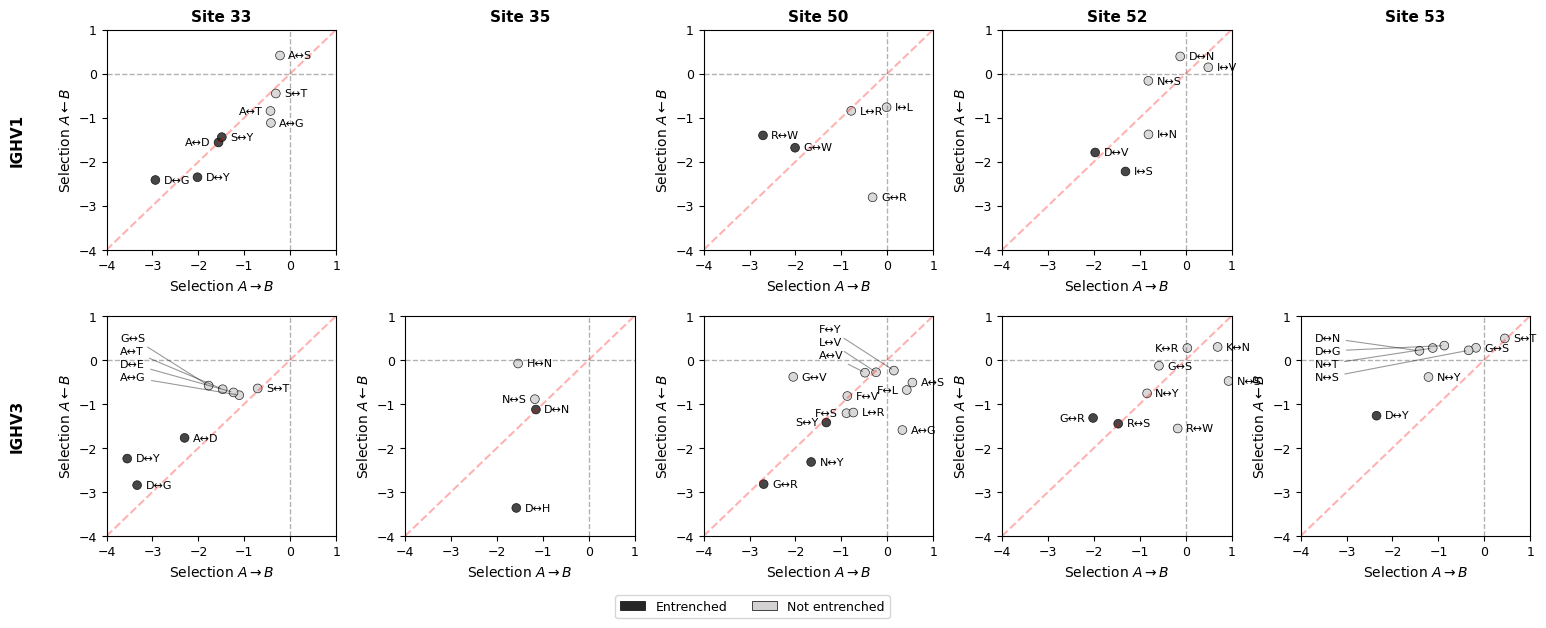

In [9]:
import seaborn as sns

numbering_scheme = 'chothia'

fig, axes = plt.subplots(2, n_sites, figsize=(3.2 * n_sites, 6))

TITLE_SIZE = 11
LABEL_SIZE = 10
TICK_SIZE = 9
ANNOT_SIZE = 8

# Annotation overrides from solvent_accessibility_analysis
callout_overrides = {
    ("33", "IGHV3"): {
        "labels": {"A↔G", "D↔E", "A↔T", "G↔S"},
        "label_x": -3.7,
        "label_y_start": 0.5,
        "label_spacing": 0.3,
    },
    ("50", "IGHV3"): {
        "labels": {"F↔Y", "L↔V", "A↔V"},
        "label_x": -1.5,
        "label_y_start": 0.7,
        "label_spacing": 0.3,
    },
    ("53", "IGHV3"): {
        "labels": {"D↔N", "N↔T", "N↔S", "D↔G"},
        "label_order": ["D↔N", "D↔G", "N↔T", "N↔S"],
        "label_x": -3.7,
        "label_y_start": 0.5,
        "label_spacing": 0.3,
    },
}
force_left_overrides = {
    ("52", "IGHV3"): {"K↔R", "G↔R"},
}

for row_idx, vfam in enumerate(v_families):
    comp = f'within_{vfam}'
    for col_idx, site in enumerate(target_sites):
        ax = axes[row_idx, col_idx]

        if not has_entrenchment[(vfam, site)]:
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            entrenchment_results_df = pd.read_csv(
                f"_output/entrenchment_analysis/{numbering_scheme}/comparison_within_{vfam}.csv"
            )
            entrenchment_results_df["substitution"] = (
                entrenchment_results_df["parent_aa_1_and_target_aa_2"]
                + "↔"
                + entrenchment_results_df["parent_aa_2_and_target_aa_1"]
            )
            sd = entrenchment_results_df[entrenchment_results_df.site == site]
            sd = sd[sd["parent_aa_1_and_target_aa_2"] <= sd["parent_aa_2_and_target_aa_1"]]

            sns.scatterplot(
                data=sd,
                x="log_selection_factor_1",
                y="log_selection_factor_2",
                hue="is_entrenched",
                palette={True: "#262626", False: "#D4D2D2"},
                ax=ax,
                legend=False,
                s=40,
                alpha=0.85,
                edgecolor="black",
                linewidth=0.5,
            )
            ax.set_xlim(-4, 1)
            ax.set_ylim(-4, 1)
            ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
            ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
            ax.axline((0, 0), slope=1, linestyle="--", color="red", alpha=0.3)
            ax.tick_params(labelsize=TICK_SIZE)

            # Annotate points with overlap-aware logic
            x_offset = 0.18
            x_threshold = 0.5
            y_threshold = 0.3
            points = list(zip(sd["log_selection_factor_1"], sd["log_selection_factor_2"], sd["substitution"]))

            override = callout_overrides.get((site, vfam))
            callout_labels = override["labels"] if override else set()
            force_left = force_left_overrides.get((site, vfam), set())

            for x, y, label in points:
                if label in callout_labels:
                    continue
                if label in force_left:
                    ax.text(x - x_offset, y, label, fontsize=ANNOT_SIZE, ha="right", va="center", zorder=5)
                    continue
                has_point_to_right = any(
                    (ox > x) and (ox - x < x_threshold) and (abs(oy - y) < y_threshold)
                    for ox, oy, _ in points if (ox, oy) != (x, y)
                )
                if has_point_to_right:
                    ax.text(x - x_offset, y, label, fontsize=ANNOT_SIZE, ha="right", va="center", zorder=5)
                else:
                    ax.text(x + x_offset, y, label, fontsize=ANNOT_SIZE, ha="left", va="center", zorder=5)

            # Draw callout arrows for clustered labels
            if override:
                callout_pts = [(x, y, l) for x, y, l in points if l in callout_labels]
                if "label_order" in override:
                    order = {l: i for i, l in enumerate(override["label_order"])}
                    callout_pts.sort(key=lambda p: order.get(p[2], len(order)))
                else:
                    callout_pts.sort(key=lambda p: -p[1])
                lx = override["label_x"]
                ly_start = override["label_y_start"]
                spacing = override["label_spacing"]
                for i, (x, y, label) in enumerate(callout_pts):
                    ly = ly_start - i * spacing
                    ax.annotate(
                        label, xy=(x, y), xytext=(lx, ly),
                        fontsize=ANNOT_SIZE, ha="left", va="center",
                        arrowprops=dict(arrowstyle="-", color="black", alpha=0.4, linewidth=0.8),
                        zorder=5,
                    )

            ax.set_xlabel(r'Selection $A \rightarrow B$', fontsize=LABEL_SIZE)
            ax.set_ylabel(r'Selection $A \leftarrow B$', fontsize=LABEL_SIZE)


        if row_idx == 0:
            ax.set_title(f'Site {site}', fontsize=TITLE_SIZE, fontweight='bold')
        if col_idx == 0:
            ax.text(-0.35, 0.5, vfam+'\n', transform=ax.transAxes,
                    fontsize=TITLE_SIZE, fontweight='bold',
                    va='center', ha='center', rotation=90)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#262626', edgecolor='black', linewidth=0.5, label='Entrenched'),
    Patch(facecolor='#D4D2D2', edgecolor='black', linewidth=0.5, label='Not entrenched'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.05), frameon=True)

fig.tight_layout(rect=[0.03, 0, 1, 1], w_pad=0.1, h_pad=1.0)
fig.subplots_adjust(wspace=0.3, hspace=0.3)
fig.savefig('figures/selection_factors_for_within_vfamily_entrenched.pdf', dpi=300, bbox_inches='tight')
plt.show()
